<a href="https://colab.research.google.com/github/matildacr/Act3algoritmos/blob/main/SVM_KMeans_Actividad3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 3 — Algoritmos de aprendizaje automático

## Aprendizaje supervisado (SVM) vs. aprendizaje no supervisado (K-Means)


## 1. Descripción del conjunto de datos

- **Nombre:** Wisconsin Diagnostic Breast Cancer (WDBC).
- **Fuente:** Wolberg, W. H., Street, W. N. y Mangasarian, O. L. (1995). *Breast Cancer Wisconsin
  (Diagnostic)*. University of Wisconsin. UCI Machine Learning Repository.
- **Liga de acceso:** https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- **Archivos utilizados:** `wdbc.data` (datos) y `wdbc.names` (descripción de atributos).
- **Contexto:** conjunto clásico de diagnóstico médico. Las características se calculan a partir de una
  imagen digitalizada de una punción con aguja fina (FNA) de una masa mamaria y describen los núcleos
  celulares presentes en la imagen.

**¿Qué representa cada registro?** Un tumor de mama individual. El archivo contiene 32 columnas: un
identificador (ID), el diagnóstico (M = maligno, B = benigno) y 30 características numéricas. Estas 30
provienen de 10 mediciones base (radio, textura, perímetro, área, suavidad, compacidad, concavidad, puntos
cóncavos, simetría y dimensión fractal), cada una reportada en tres versiones: media (mean), error estándar
(error) y valor peor (worst).

**Variable objetivo (categórica):** el diagnóstico. Se convierte a una variable numérica `target` con la
codificación `0 = maligno` y `1 = benigno`.

**Variables predictoras:** las 30 características numéricas continuas que describen la forma y textura de
los núcleos celulares.

### Preguntas de análisis

- **Pregunta supervisada:** ¿Es posible predecir si un tumor es maligno o benigno a partir de sus
  características numéricas?
- **Pregunta no supervisada:** ¿Existen agrupamientos naturales entre los tumores cuando no se utiliza
  el diagnóstico, y esos grupos coinciden con la distinción maligno/benigno?

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Carga de datos y revisión inicial

In [23]:

base = ["radius", "texture", "perimeter", "area", "smoothness",
        "compactness", "concavity", "concave points", "symmetry", "fractal dimension"]
feature_names = ([f"mean {b}" for b in base] +
                 [f"{b} error" for b in base] +
                 [f"worst {b}" for b in base])
columnas = ["id", "diagnosis"] + feature_names

df_raw = pd.read_csv("wdbc.data", header=None, names=columnas)
print("Dimensiones del archivo original:", df_raw.shape)
df_raw.head()

Dimensiones del archivo original: (569, 32)


,id,diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Limpieza necesaria

Se aplican únicamente las transformaciones indispensables:

1. **Selección de columnas pertinentes:** se elimina la columna `id`, ya que es un identificador sin
   valor predictivo.
2. **Conversión de tipos:** la columna categórica `diagnosis` (M/B) se convierte a una variable numérica
   `target` con la codificación `0 = maligno` y `1 = benigno`.

In [24]:
# 1. Se descarta el identificador y 2. se codifica el diagnóstico como variable numérica
df = df_raw.drop(columns=["id"]).copy()
df["target"] = df["diagnosis"].map({"M": 0, "B": 1})   # 0 = maligno, 1 = benigno

print("Dimensiones tras la limpieza:", df.shape)
df[["diagnosis", "target"] + feature_names[:3]].head()

Dimensiones tras la limpieza: (569, 32)


,diagnosis,target,mean radius,mean texture,mean perimeter
0,M,0,17.99,10.38,122.80
1,M,0,20.57,17.77,132.90
2,M,0,19.69,21.25,130.00
3,M,0,11.42,20.38,77.58
4,M,0,20.29,14.34,135.10


In [25]:
# Número de registros y de variables predictoras
print("Número de registros:", df.shape[0])
print("Número de variables predictoras:", len(feature_names))

Número de registros: 569
Número de variables predictoras: 30


In [26]:
# Tipos de datos de las variables predictoras y de la variable objetivo
print("Tipos de datos de las variables predictoras:")
print(df[feature_names].dtypes.value_counts())
print()
print("Tipo de la variable objetivo 'target':", df["target"].dtype)

Tipos de datos de las variables predictoras:
float64    30
Name: count, dtype: int64

Tipo de la variable objetivo 'target': int64


In [27]:
# Valores faltantes y registros duplicados
print("Total de valores faltantes:", int(df.isnull().sum().sum()))
print("Registros duplicados:", int(df.duplicated().sum()))

Total de valores faltantes: 0
Registros duplicados: 0


In [28]:
# Distribución de la variable objetivo
conteo = df["target"].value_counts().sort_index()
print("Distribución de clases (0 = maligno, 1 = benigno):")
print(conteo)
print()
print("Proporción (%):")
print((df["target"].value_counts(normalize=True).sort_index() * 100).round(2))

Distribución de clases (0 = maligno, 1 = benigno):
target
0    212
1    357
Name: count, dtype: int64

Proporción (%):
target
0    37.26
1    62.74
Name: proportion, dtype: float64


**Interpretación de la revisión inicial:** el archivo tiene 569 registros. Tras eliminar el ID quedan
30 variables predictoras (todas numéricas de tipo `float64`) más la variable objetivo. No existen valores
faltantes ni registros duplicados, por lo que no se requiere limpieza adicional. La variable objetivo está
algo desbalanceada: 357 casos benignos (62.7 %) y 212 malignos (37.3 %), lo que hace conveniente
**estratificar** la partición de entrenamiento y prueba.

## 3. Selección de variables, separación del objetivo y escalamiento

Se seleccionan las 30 variables numéricas como predictoras y se separa la variable objetivo. Se conserva
una copia de las etiquetas reales **únicamente** para la evaluación del modelo supervisado y para la
comparación final con los clusters; estas etiquetas no se utilizan para entrenar K-Means.

In [29]:
# Predictoras (X) y variable objetivo (y)
X = df[feature_names].copy()
y = df["target"].copy()

# Copia de las etiquetas reales en texto, solo para evaluación y comparación final
y_labels = y.map({0: "maligno", 1: "benigno"})

print("Dimensiones de X (predictoras):", X.shape)
print("Dimensiones de y (objetivo):", y.shape)

Dimensiones de X (predictoras): (569, 30)
Dimensiones de y (objetivo): (569,)


**¿Por qué SVM y K-Means requieren variables en escalas comparables?**

Ambos algoritmos se basan en **distancias** en el espacio de las variables. En este dataset las escalas
son muy dispares: por ejemplo, `mean area` toma valores de cientos o miles, mientras que `mean smoothness`
está entre 0 y 1. Sin escalamiento, las variables de mayor magnitud dominarían el cálculo:

- **SVM** busca el hiperplano de máximo margen y, con kernel RBF, mide similitud por distancia; una variable
  con valores grandes distorsionaría el margen y la frontera de decisión.
- **K-Means** asigna cada punto al centroide más cercano según la distancia euclidiana; sin escalar, la
  variable de mayor rango determinaría casi por completo los grupos.

Por ello se aplica `StandardScaler`, que deja cada variable con media 0 y desviación estándar 1, otorgando
un peso comparable a todas.

In [30]:
# El escalamiento para SVM se integra dentro del Pipeline (se ajusta solo con datos de entrenamiento).
# Para K-Means se escala el conjunto completo, ya que es un análisis exploratorio sin partición.
scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(X)
print("Media aproximada tras el escalamiento:", round(float(X_scaled.mean()), 6))
print("Desviación estándar tras el escalamiento:", round(float(X_scaled.std()), 6))

Media aproximada tras el escalamiento: -0.0
Desviación estándar tras el escalamiento: 1.0


## 4. Análisis supervisado: máquinas de soporte vectorial (SVM)

### 4.1 Partición en entrenamiento y prueba

Se divide el conjunto en 80 % para entrenamiento y 20 % para prueba, con una **semilla fija**
(`random_state = 42`) y **estratificación** por la variable objetivo para conservar la proporción de clases.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y                 # conserva la proporción maligno/benigno en ambos conjuntos
)

print("Entrenamiento:", X_train.shape[0], "registros")
print("Prueba:", X_test.shape[0], "registros")
print("Proporción de clases en entrenamiento:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2).to_dict())
print("Proporción de clases en prueba:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2).to_dict())

Entrenamiento: 455 registros
Prueba: 114 registros
Proporción de clases en entrenamiento:
{0: 37.36, 1: 62.64}
Proporción de clases en prueba:
{0: 36.84, 1: 63.16}


**¿Por qué esta división permite evaluar el desempeño con datos no vistos?**
El modelo aprende únicamente con el 80 % de entrenamiento y se evalúa con el 20 % restante, que no
participó en el ajuste. Así se estima cómo generalizaría ante casos nuevos y se detecta el sobreajuste;
si el modelo solo memorizara los datos de entrenamiento, su desempeño en la prueba sería bajo. La semilla
fija hace que la partición sea reproducible.

### 4.2 Entrenamiento de dos modelos SVM

Cada modelo integra el escalamiento y el clasificador dentro de un **Pipeline**, de modo que el
`StandardScaler` se ajusta únicamente con los datos de entrenamiento en cada partición, evitando fuga
de información desde el conjunto de prueba.

In [32]:
def entrenar_svm(kernel, **kwargs):
    """Crea, entrena y evalúa un SVM con escalamiento dentro de un Pipeline."""
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel=kernel, random_state=RANDOM_STATE, **kwargs))
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    metricas = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1-score":  f1_score(y_test, y_pred),
    }
    return pipe, y_pred, metricas

# Modelo 1: kernel lineal
pipe_lineal, pred_lineal, met_lineal = entrenar_svm("linear")

# Modelo 2: kernel RBF
pipe_rbf, pred_rbf, met_rbf = entrenar_svm("rbf")

print("Modelos entrenados correctamente.")

Modelos entrenados correctamente.


In [33]:
# Tabla comparativa de resultados
tabla_svm = pd.DataFrame([
    {"Modelo SVM": "Modelo 1", "Kernel": "Lineal", **met_lineal},
    {"Modelo SVM": "Modelo 2", "Kernel": "RBF",    **met_rbf},
]).round(4)

tabla_svm

,Modelo SVM,Kernel,Accuracy,Precision,Recall,F1-score
0,Modelo 1,Lineal,0.9737,0.9859,0.9722,0.9790
1,Modelo 2,RBF,0.9825,0.9861,0.9861,0.9861


**Nota sobre las métricas:** el problema es binario (maligno/benigno), por lo que `precision`,
`recall` y `F1-score` se calculan sobre la clase positiva por defecto (benigno = 1). Ambos modelos
alcanzan un desempeño muy alto; el **kernel RBF resulta ligeramente superior** en las cuatro métricas,
por lo que se toma como el modelo de mejor desempeño.

### 4.3 Matriz de confusión del mejor modelo

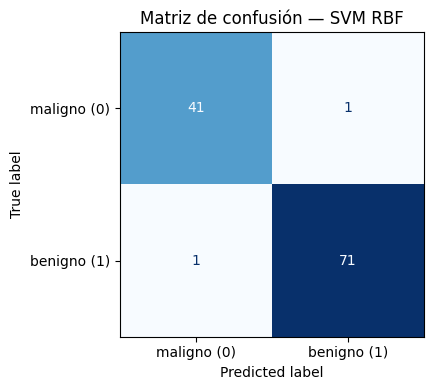

[[41  1]
 [ 1 71]]


In [34]:
# Se selecciona automáticamente el modelo con mayor F1-score
if met_rbf["F1-score"] >= met_lineal["F1-score"]:
    mejor_nombre, mejor_pred = "SVM RBF", pred_rbf
else:
    mejor_nombre, mejor_pred = "SVM Lineal", pred_lineal

cm = confusion_matrix(y_test, mejor_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["maligno (0)", "benigno (1)"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusión — {mejor_nombre}")
plt.tight_layout()
plt.show()

print(cm)

**Interpretación de la matriz de confusión (SVM RBF):**

- La diagonal concentra la gran mayoría de los casos: el modelo clasifica correctamente casi todos los
  tumores de la muestra de prueba.
- Los errores son mínimos: un caso maligno clasificado como benigno (**falso negativo**) y un caso benigno
  clasificado como maligno (**falso positivo**).
- El **falso negativo** es el error más delicado en un contexto médico, porque significa no detectar un
  tumor maligno; por eso el `recall` de la clase maligna es una métrica crítica en este problema.
- La clase benigna, más numerosa, resulta algo más fácil de identificar.

**¿Por qué no basta con revisar la accuracy?** Con clases desbalanceadas, un modelo podría alcanzar
accuracy alta acertando sobre todo la clase mayoritaria y fallando en la minoritaria (la maligna, la más
importante de detectar). Precision, recall y F1-score, junto con la matriz de confusión, muestran el tipo
de error cometido en cada clase, información que la accuracy por sí sola oculta.

### 4.4 Comparación de hiperparámetros

Se compara el efecto del parámetro de regularización **C** en el modelo con kernel RBF, manteniendo lo
demás constante.

In [35]:
valores_C = [0.1, 1, 10]
filas = []
for C in valores_C:
    _, _, met = entrenar_svm("rbf", C=C)
    filas.append({"C": C, **{k: round(v, 4) for k, v in met.items()}})

tabla_C = pd.DataFrame(filas)
tabla_C

,C,Accuracy,Precision,Recall,F1-score
0,0.1,0.9474,0.9459,0.9722,0.9589
1,1.0,0.9825,0.9861,0.9861,0.9861
2,10.0,0.9737,0.9859,0.9722,0.9790


**Efecto del hiperparámetro C (y de gamma) en el SVM:**

El parámetro **C** controla el equilibrio entre maximizar el margen y clasificar bien los datos de
entrenamiento:

- **C pequeño (0.1):** el modelo tolera más errores, produce un **margen amplio** y una frontera de
  decisión más simple. Puede quedar **subajustado** (en la tabla, C = 0.1 obtiene el desempeño más bajo).
- **C grande (10):** el modelo penaliza fuertemente cada error, genera un **margen estrecho** y una
  frontera más compleja que se ciñe a los datos de entrenamiento, con mayor **riesgo de sobreajuste**.
- **C intermedio (1):** ofrece el mejor equilibrio y el desempeño más alto en este caso.

El parámetro **gamma** (propio del kernel RBF) regula el alcance de cada punto: un gamma alto hace la
frontera muy flexible y localizada (riesgo de sobreajuste), mientras que un gamma bajo la suaviza. En
conjunto, C y gamma determinan la complejidad de la frontera y el balance entre sesgo y varianza.

## 5. Análisis no supervisado: K-Means

Se elimina temporalmente la variable objetivo y se aplica K-Means sobre **las mismas variables numéricas
escaladas**. Las etiquetas reales no se usan para entrenar ni para elegir el número de grupos.

### 5.1 Selección del número de grupos (método del codo y silhouette)

In [36]:
valores_k = range(2, 7)   # k de 2 a 6
inercias = []
silhouettes = []

for k in valores_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    etiquetas_k = km.fit_predict(X_scaled)   # se usa X_scaled, sin la variable objetivo
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, etiquetas_k))

resumen_k = pd.DataFrame({
    "k": list(valores_k),
    "Inercia (codo)": np.round(inercias, 1),
    "Silhouette": np.round(silhouettes, 4),
})
resumen_k

,k,Inercia (codo),Silhouette
0,2,11595.5,0.3434
1,3,10061.8,0.3144
2,4,9259.0,0.2833
3,5,8558.7,0.1582
4,6,7970.3,0.1604


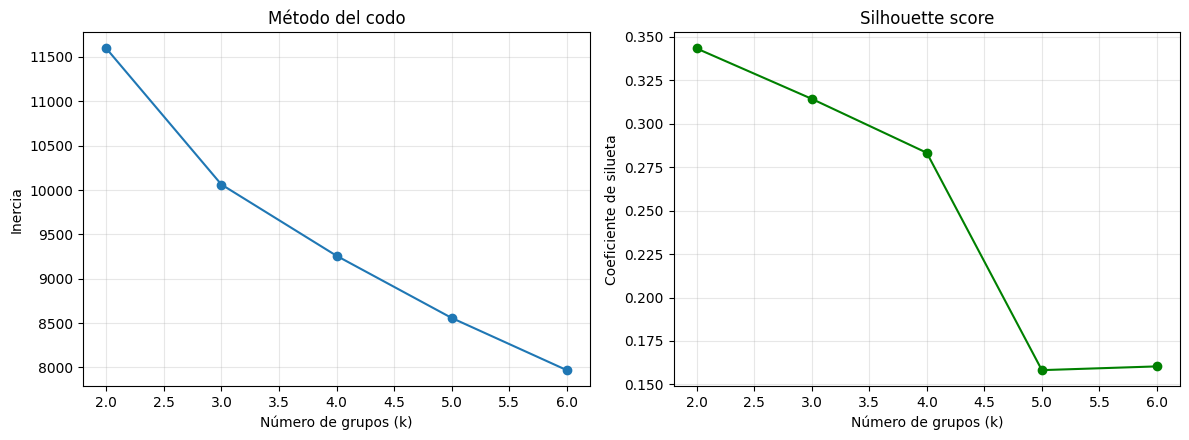

In [37]:
# Gráficas del método del codo y del silhouette score
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(list(valores_k), inercias, marker="o")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de grupos (k)")
axes[0].set_ylabel("Inercia")
axes[0].grid(alpha=0.3)

axes[1].plot(list(valores_k), silhouettes, marker="o", color="green")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Número de grupos (k)")
axes[1].set_ylabel("Coeficiente de silueta")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Justificación del número de grupos:** el método del codo muestra el descenso más pronunciado de la
inercia al pasar de k = 2 hacia valores mayores, sin un quiebre claro posterior, y el **silhouette score
es máximo en k = 2** (0.34), disminuyendo para k mayores. Ambos criterios coinciden, por lo que se
selecciona **k = 2** como el número de grupos más adecuado. Este resultado es coherente con la naturaleza
del problema, que distingue dos diagnósticos.

### 5.2 Caracterización de los clusters

In [38]:
# Ajuste final de K-Means con k = 2
K_ELEGIDO = 2
kmeans = KMeans(n_clusters=K_ELEGIDO, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Tamaño de cada cluster
tamanos = df["cluster"].value_counts().sort_index()
print("Tamaño de cada cluster:")
print(tamanos)

Tamaño de cada cluster:
cluster
0    375
1    194
Name: count, dtype: int64


In [39]:
# Valores promedio de algunas variables principales por cluster (en la escala original)
variables_principales = ["mean radius", "mean texture", "mean perimeter",
                         "mean area", "mean concavity", "mean concave points"]
resumen_clusters = df.groupby("cluster")[variables_principales].mean().round(2)
resumen_clusters

,mean radius,mean texture,mean perimeter,mean area,mean concavity,mean concave points
cluster,,,,,,
0,12.43,18.26,79.82,486.77,0.04,0.03
1,17.41,21.28,115.45,979.86,0.18,0.09


**Descripción de los grupos:** los dos clusters se distinguen con claridad por el **tamaño y la
irregularidad** de los núcleos celulares. Uno de los grupos reúne tumores con valores promedio bajos de
radio, perímetro, área y concavidad, es decir, células más pequeñas y regulares. El otro grupo concentra
tumores con valores notablemente más altos en esas mismas variables, lo que indica células más grandes e
irregulares. El patrón que separa a los clusters es, por tanto, la **magnitud general de las mediciones
morfológicas**: a mayor tamaño e irregularidad, mayor probabilidad de que el tumor sea maligno. Una
interpretación preliminar es que K-Means está capturando de forma no supervisada la misma distinción
clínica entre tumores de aspecto benigno y maligno.

### 5.3 Visualización con PCA

Varianza explicada: PC1 = 44.3 %  PC2 = 19.0 %


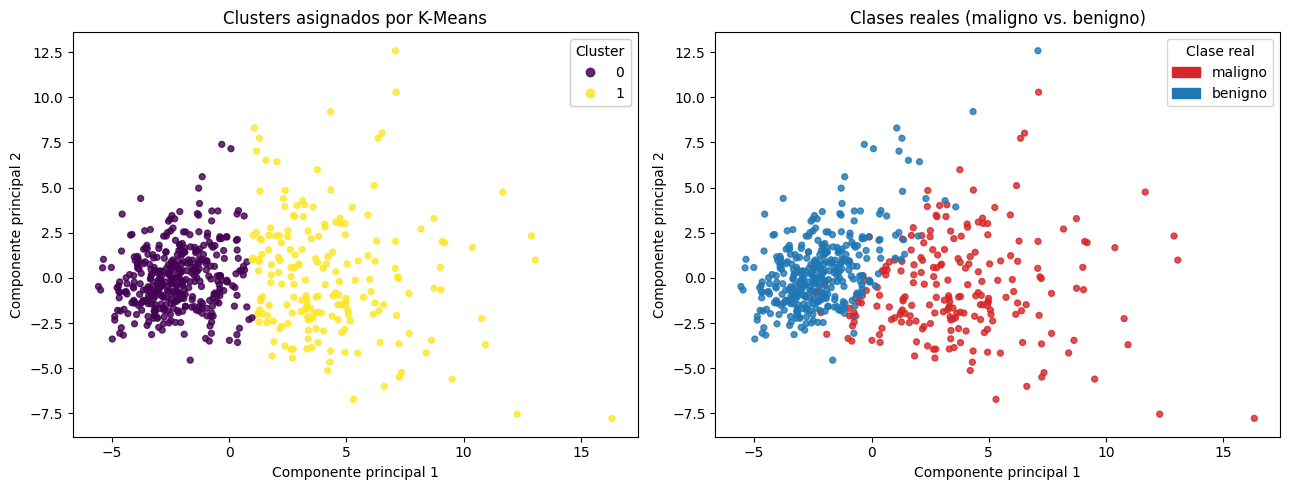

In [40]:
# Proyección de las 30 variables escaladas a 2 dimensiones con PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
componentes = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_
print("Varianza explicada: PC1 =", round(var_exp[0]*100, 1), "%  PC2 =", round(var_exp[1]*100, 1), "%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda: grupos asignados por K-Means (no supervisado)
sc0 = axes[0].scatter(componentes[:, 0], componentes[:, 1], c=df["cluster"], cmap="viridis", s=18, alpha=0.8)
axes[0].set_title("Clusters asignados por K-Means")
axes[0].set_xlabel("Componente principal 1")
axes[0].set_ylabel("Componente principal 2")
legend0 = axes[0].legend(*sc0.legend_elements(), title="Cluster")
axes[0].add_artist(legend0)

# Derecha: clases reales (solo para comparación visual, NO se usaron para entrenar K-Means)
colores = y.map({0: "tab:red", 1: "tab:blue"})
axes[1].scatter(componentes[:, 0], componentes[:, 1], c=colores, s=18, alpha=0.8)
axes[1].set_title("Clases reales (maligno vs. benigno)")
axes[1].set_xlabel("Componente principal 1")
axes[1].set_ylabel("Componente principal 2")
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color="tab:red", label="maligno"), Patch(color="tab:blue", label="benigno")], title="Clase real")

plt.tight_layout()
plt.show()

### 5.4 Comparación de clusters con las clases reales

In [41]:
# Tabla cruzada entre los clusters y las clases reales
comparacion = pd.crosstab(df["cluster"], y_labels, rownames=["Cluster"], colnames=["Clase real"])
comparacion

Clase real,benigno,maligno
Cluster,,
0,339,36
1,18,176


**Análisis de la correspondencia:** existe una **correspondencia parcial fuerte** entre los clusters y
las clases reales. Un cluster agrupa mayoritariamente tumores benignos y el otro concentra la mayoría de
los malignos, con solo una fracción de casos mezclados. Las gráficas de PCA muestran el mismo panorama:
los dos grupos de K-Means ocupan regiones muy similares a las de las clases reales, con cierto traslape en
la zona fronteriza.

**¿Por qué no debe esperarse una coincidencia exacta?** K-Means agrupa las observaciones por **similitud
geométrica** (cercanía en el espacio de las variables), sin conocer el diagnóstico. No optimiza la
separación entre maligno y benigno, sino la compacidad de los grupos. Por eso los casos que geométricamente
se ubican cerca de la frontera pueden quedar en el cluster "equivocado" respecto a su etiqueta clínica. La
alta correspondencia observada indica que la estructura natural de los datos está muy alineada con la
distinción diagnóstica, pero no tiene por qué reproducirla con exactitud.

## 6. Conclusión

**¿Qué enfoque fue más fácil de interpretar?** El **aprendizaje supervisado (SVM)** ofreció resultados más
directos de interpretar, ya que sus métricas (accuracy, precision, recall, F1-score) y la matriz de
confusión responden de forma clara a la pregunta planteada.

**¿Qué información aportó SVM?** Permitió **predecir el diagnóstico** con alto desempeño (accuracy de
0.98 con kernel RBF) y, mediante la matriz de confusión, identificar qué tipo de errores comete el modelo,
en particular los falsos negativos, críticos en un contexto médico. La comparación de valores de C mostró
cómo la regularización afecta el margen, la complejidad de la frontera y el riesgo de sobreajuste.

**¿Qué patrones descubrió K-Means?** Sin usar las etiquetas, identificó **dos grupos naturales** que se
distinguen por el tamaño e irregularidad de los núcleos celulares y que corresponden en buena medida con la
separación entre tumores benignos y malignos, revelando que esa estructura existe de forma intrínseca en
los datos.

**Limitaciones identificadas:** K-Means no reproduce exactamente las clases reales porque agrupa por
similitud geométrica y no por la variable objetivo; además, es sensible a la escala (resuelta con
`StandardScaler`) y requiere fijar k de antemano. El SVM, por su parte, depende de una buena elección de
hiperparámetros y de que los datos estén escalados.

**¿En qué problema se usaría cada técnica?** El **aprendizaje supervisado (SVM)** es apropiado cuando se
dispone de etiquetas y el objetivo es **predecir una clase conocida** (por ejemplo, diagnosticar un tumor).
El **aprendizaje no supervisado (K-Means)** es útil cuando **no hay etiquetas** y se busca **explorar la
estructura** de los datos o descubrir grupos (por ejemplo, segmentar observaciones para generar hipótesis).
En síntesis, el enfoque supervisado predice categorías previamente definidas, mientras que el no supervisado
explora agrupamientos sin conocerlas.

## 7. Exportación del CSV procesado

In [42]:
# Se exporta el conjunto procesado, incluyendo la etiqueta real y el cluster asignado por K-Means
df_procesado = df.copy()
df_procesado["diagnostico_real"] = y_labels.values
df_procesado.to_csv("wdbc_procesado.csv", index=False)
print("Archivo 'wdbc_procesado.csv' generado con", df_procesado.shape[0],
      "registros y", df_procesado.shape[1], "columnas.")
df_procesado.head()

Archivo 'wdbc_procesado.csv' generado con 569 registros y 34 columnas.


,diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,cluster,diagnostico_real
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,1,maligno
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,1,maligno
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,1,maligno
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,1,maligno
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,1,maligno
